# **Task 1**

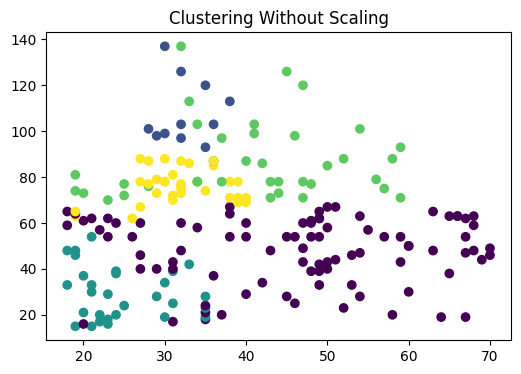

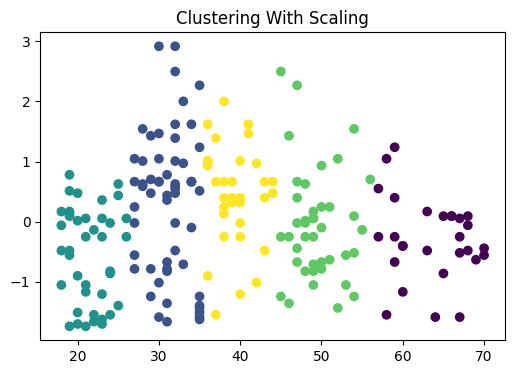

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

mall_data = pd.read_csv("Mall_Customers.csv")
customer_features = mall_data.drop("CustomerID", axis=1)
customer_features = pd.get_dummies(customer_features, drop_first=True)

kmeans_raw = KMeans(n_clusters=5, random_state=42)
labels_raw = kmeans_raw.fit_predict(customer_features)

plt.figure(figsize=(6,4))
plt.scatter(customer_features.iloc[:, 0], customer_features.iloc[:, 1], c=labels_raw)
plt.title("Clustering Without Scaling")
plt.show()

scaled_features = customer_features.copy()
scaler = StandardScaler()
scale_cols = scaled_features.columns.drop("Age")

scaled_features[scale_cols] = scaler.fit_transform(scaled_features[scale_cols])
kmeans_scaled = KMeans(n_clusters=5, random_state=42)
labels_scaled = kmeans_scaled.fit_predict(scaled_features)

plt.figure(figsize=(6,4))
plt.scatter(scaled_features.iloc[:, 0], scaled_features.iloc[:, 1], c=labels_scaled)
plt.title("Clustering With Scaling")
plt.show()

# **Task 2**

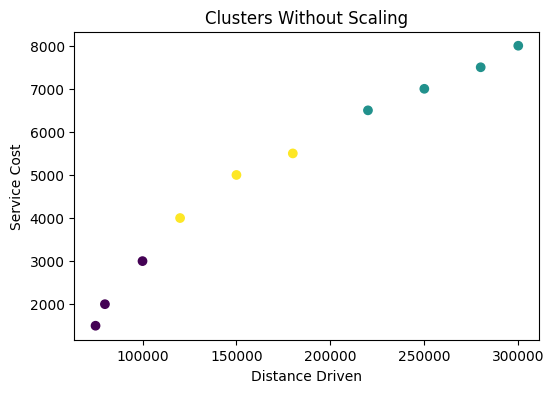

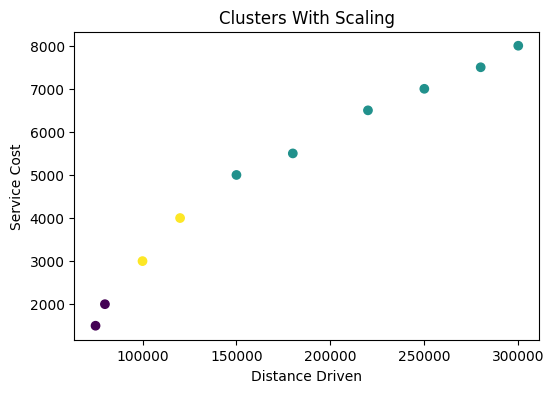

 serial_no  distance_driven  efficiency  service_cost      type  Cluster_NoScaling  Cluster_Scaling
         5           150000          15          5000       SUV                  2                1
         3           120000          18          4000     Sedan                  2                2
         8           250000          10          7000     Truck                  1                1
         2            80000          22          2000 Hatchback                  0                0
         4           100000          20          3000     Sedan                  0                2
         7           220000          12          6500     Truck                  1                1
         6           180000          16          5500       SUV                  2                1
        10           300000           8          8000     Truck                  1                1
         1            75000          24          1500 Hatchback                  0                0


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

vehicle_data = {
    'serial_no': [5,3,8,2,4,7,6,10,1,9],
    'distance_driven': [150000,120000,250000,80000,100000,220000,180000,300000,75000,280000],
    'efficiency': [15,18,10,22,20,12,16,8,24,9],
    'service_cost': [5000,4000,7000,2000,3000,6500,5500,8000,1500,7500],
    'type': ['SUV','Sedan','Truck','Hatchback','Sedan','Truck','SUV','Truck','Hatchback','SUV']
}

vehicles_df = pd.DataFrame(vehicle_data)
encoded_df = pd.get_dummies(vehicles_df, columns=['type'])

model_without_scaling = KMeans(n_clusters=3, random_state=42)
clusters_raw = model_without_scaling.fit_predict(encoded_df)
vehicles_df['Cluster_NoScaling'] = clusters_raw

plt.figure(figsize=(6,4))
plt.scatter(vehicles_df['distance_driven'], vehicles_df['service_cost'], c=clusters_raw)
plt.title("Clusters Without Scaling")
plt.xlabel("Distance Driven")
plt.ylabel("Service Cost")
plt.show()

scaler = StandardScaler()
scaled_values = scaler.fit_transform(encoded_df)

model_with_scaling = KMeans(n_clusters=3, random_state=42)
clusters_scaled = model_with_scaling.fit_predict(scaled_values)
vehicles_df['Cluster_Scaling'] = clusters_scaled

plt.figure(figsize=(6,4))
plt.scatter(vehicles_df['distance_driven'], vehicles_df['service_cost'], c=clusters_scaled)
plt.title("Clusters With Scaling")
plt.xlabel("Distance Driven")
plt.ylabel("Service Cost")
plt.show()

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(vehicles_df.to_string(index=False))

# **Task 3**

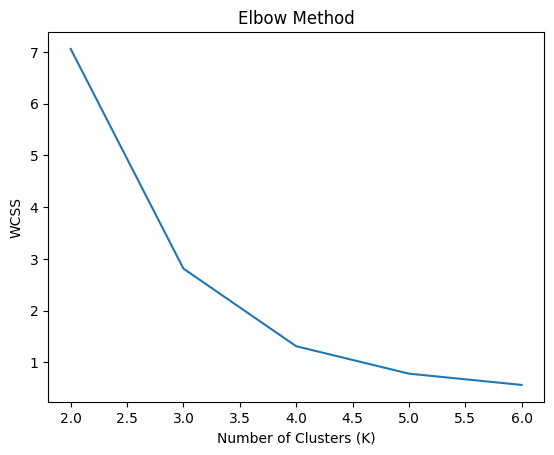

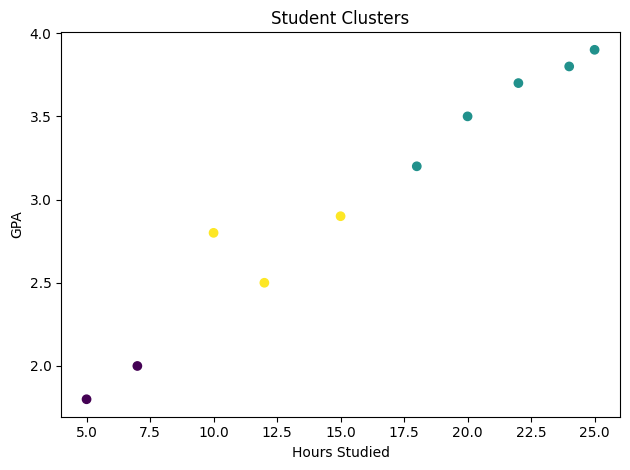

 id  gpa  hours_studied  attendance  Cluster
  1  3.5             20          90        1
  2  2.8             10          70        2
  3  3.9             25          95        1
  4  1.8              5          60        0
  5  2.5             12          75        2
  6  3.2             18          85        1
  7  3.7             22          92        1
  8  2.0              7          65        0
  9  2.9             15          80        2
 10  3.8             24          96        1


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

student_data = {
    'id': [1,2,3,4,5,6,7,8,9,10],
    'gpa': [3.5,2.8,3.9,1.8,2.5,3.2,3.7,2.0,2.9,3.8],
    'hours_studied': [20,10,25,5,12,18,22,7,15,24],
    'attendance': [90,70,95,60,75,85,92,65,80,96]
}

students_df = pd.DataFrame(student_data)
features = students_df[['gpa', 'hours_studied', 'attendance']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

inertia_values = []
k_range = range(2, 7)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_features)
    inertia_values.append(model.inertia_)

plt.plot(k_range, inertia_values)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

final_model = KMeans(n_clusters=3, random_state=42)
cluster_labels = final_model.fit_predict(scaled_features)
students_df['Cluster'] = cluster_labels

plt.scatter(students_df['hours_studied'], students_df['gpa'], c=cluster_labels)
plt.xlabel("Hours Studied")
plt.ylabel("GPA")
plt.title("Student Clusters")

plt.tight_layout()
plt.show()
print(students_df.to_string(index=False))